In [1]:
pip install tensorflow 

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install opencv-python


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install matplotlib


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install tqdm

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.layers import BatchNormalization
from sklearn import metrics
from sklearn.metrics import classification_report
import time
from tqdm import tqdm

2025-04-30 03:47:50.831411: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9360] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-30 03:47:50.831462: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-30 03:47:50.831507: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1537] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-30 03:47:50.842271: I tensorflow/core/platform/cpu_feature_guard.cc:183] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [7]:
from tensorflow.python.client import  device_lib
device_lib.list_local_devices()

2025-04-30 03:47:55.352675: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1883] Created device /device:GPU:0 with 31118 MB memory:  -> device: 0, name: Tesla V100-SXM3-32GB, pci bus id: 0000:36:00.0, compute capability: 7.0
2025-04-30 03:47:55.354004: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1883] Created device /device:GPU:1 with 31118 MB memory:  -> device: 1, name: Tesla V100-SXM3-32GB, pci bus id: 0000:39:00.0, compute capability: 7.0
2025-04-30 03:47:55.355157: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1883] Created device /device:GPU:2 with 31118 MB memory:  -> device: 2, name: Tesla V100-SXM3-32GB, pci bus id: 0000:57:00.0, compute capability: 7.0
2025-04-30 03:47:55.356237: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1883] Created device /device:GPU:3 with 31118 MB memory:  -> device: 3, name: Tesla V100-SXM3-32GB, pci bus id: 0000:5c:00.0, compute capability: 7.0


[name: "/device:CPU:0"
 device_type: "CPU"
 memory_limit: 268435456
 locality {
 }
 incarnation: 3821171298014376664
 xla_global_id: -1,
 name: "/device:GPU:0"
 device_type: "GPU"
 memory_limit: 32630571008
 locality {
   bus_id: 1
   links {
     link {
       device_id: 1
       type: "StreamExecutor"
       strength: 1
     }
     link {
       device_id: 2
       type: "StreamExecutor"
       strength: 1
     }
     link {
       device_id: 3
       type: "StreamExecutor"
       strength: 1
     }
   }
 }
 incarnation: 12430571817563732839
 physical_device_desc: "device: 0, name: Tesla V100-SXM3-32GB, pci bus id: 0000:36:00.0, compute capability: 7.0"
 xla_global_id: 416903419,
 name: "/device:GPU:1"
 device_type: "GPU"
 memory_limit: 32630571008
 locality {
   bus_id: 1
   links {
     link {
       type: "StreamExecutor"
       strength: 1
     }
     link {
       device_id: 2
       type: "StreamExecutor"
       strength: 1
     }
     link {
       device_id: 3
       type: "S

In [8]:
# Set random seed for Python's built-in random number generator
import random
random_seed = 42
random.seed(random_seed)

# Set random seed for NumPy
np.random.seed(random_seed)

# Set random seed for TensorFlow
tf.random.set_seed(random_seed)

In [9]:
# Define dataset path and categories
DATADIR = "/home/ankitk/rf/data/"
CATEGORIES = ["0", "1", "2", "3", "4", "5","6", "7", "8", "9","10", "11", "12", "13", "14", "15", "16", "17", "18", "19", "20", "21", "22", "23"]  # ["0", "1", ..., "23"]

dataset = []
img_size = (224, 224)  # Resize images to 224x224

# Load binary images (grayscale)
for category in tqdm(CATEGORIES, desc="Processing Categories"):  
    path = os.path.join(DATADIR, category)  
    class_num = CATEGORIES.index(category)  # Label for category
    
    for img in os.listdir(path):
        try:
            img_path = os.path.join(path, img)
            
            # Load binary image (assumes images are already binarized)
            img_array = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            if img_array is None:
                print(f"Skipping corrupted image: {img_path}")
                continue  # Skip invalid images

            # Resize to (224, 224)
            resized_array = cv2.resize(img_array, img_size)

            # Append to dataset
            dataset.append([resized_array, class_num])
        except Exception as e:
            print(f"Error processing {img}: {e}")

# Step 2: Separate Features (X) and Labels (Y)
X = []
Y = []

for features, label in dataset:
    X.append(features)
    Y.append(label)

# Convert to NumPy arrays
X = np.array(X).reshape(-1, 224, 224, 1).astype("float32") / 255.0  # Normalize to 0-1
Y = np.array(Y).astype("int")  # Keep Y as integer class labels

# Ensure dataset sizes match
assert len(X) == len(Y), f"Mismatch: X({len(X)}) and Y({len(Y)})"

# Step 3: Split Dataset (70% Train, 20% Test, 10% Validation)
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, random_state=42)  # 30% temp (to split further)
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=2/3, random_state=42)  # Split 30% into 20% Test, 10% Val

print(f"✅ Dataset Split: Train({len(X_train)}), Test({len(X_test)}), Validation({len(X_val)})")

# Step 4: Calculate Class Weights Automatically
from sklearn.utils import class_weight

# Compute class weights to handle class imbalance
class_weights = class_weight.compute_class_weight(
    'balanced', 
    classes=np.unique(Y_train), 
    y=Y_train
)

# Convert class weights into a dictionary for Keras
class_weight_dict = dict(enumerate(class_weights))

print("Class Weights: ", class_weight_dict)

Processing Categories:   4%|▍         | 1/24 [00:01<00:25,  1.12s/it]

Skipping corrupted image: /home/ankitk/rf/data/0/.ipynb_checkpoints


Processing Categories: 100%|██████████| 24/24 [00:22<00:00,  1.05it/s]


✅ Dataset Split: Train(10138), Test(2898), Validation(1448)
Class Weights:  {0: 0.8800347222222222, 1: 0.8709621993127148, 2: 0.8533670033670033, 3: 0.7765012254901961, 4: 0.8364686468646865, 5: 0.823424301494477, 6: 0.8364686468646865, 7: 0.8046031746031747, 8: 1.7101889338731444, 9: 0.8186369509043928, 10: 1.1799348230912476, 11: 2.0115079365079365, 12: 1.069409282700422, 13: 1.5249699157641396, 14: 1.1175044091710757, 15: 1.045585808580858, 16: 1.0887027491408934, 17: 1.0228006456820016, 18: 1.020330112721417, 19: 1.0481803143093467, 20: 0.9892661982825918, 21: 1.0033650039588282, 22: 1.0033650039588282, 23: 1.020330112721417}


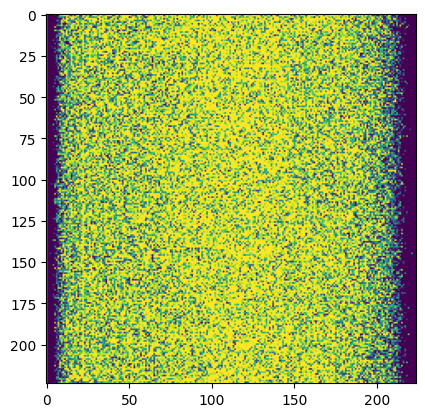

In [10]:
import matplotlib.pyplot as plt
plt.imshow(X[1])

In [11]:
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import tensorflow.keras.backend as K
import numpy as np
import matplotlib.pyplot as plt



Training model variant: nano


2025-04-30 03:48:21.237852: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1883] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 31118 MB memory:  -> device: 0, name: Tesla V100-SXM3-32GB, pci bus id: 0000:36:00.0, compute capability: 7.0
2025-04-30 03:48:21.238678: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1883] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 31118 MB memory:  -> device: 1, name: Tesla V100-SXM3-32GB, pci bus id: 0000:39:00.0, compute capability: 7.0
2025-04-30 03:48:21.239482: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1883] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 31118 MB memory:  -> device: 2, name: Tesla V100-SXM3-32GB, pci bus id: 0000:57:00.0, compute capability: 7.0
2025-04-30 03:48:21.240345: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1883] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 31118 MB memory:  -> device: 3, name: Tesla V100-SXM3-32GB, pci bus id

Epoch 1/25


2025-04-30 03:48:34.789404: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8907
2025-04-30 03:48:36.238302: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7d367af72420 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-04-30 03:48:36.238337: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): Tesla V100-SXM3-32GB, Compute Capability 7.0
2025-04-30 03:48:36.238347: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (1): Tesla V100-SXM3-32GB, Compute Capability 7.0
2025-04-30 03:48:36.238354: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (2): Tesla V100-SXM3-32GB, Compute Capability 7.0
2025-04-30 03:48:36.238360: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (3): Tesla V100-SXM3-32GB, Compute Capability 7.0
2025-04-30 03:48:36.243351: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir

317/317 [==============================] - 31s 49ms/step - loss: 2.2772 - accuracy: 0.2790 - val_loss: 5.0411 - val_accuracy: 0.0449 - lr: 1.0000e-04
Epoch 2/25
317/317 [==============================] - 14s 43ms/step - loss: 1.5473 - accuracy: 0.4542 - val_loss: 6.1778 - val_accuracy: 0.0477 - lr: 1.0000e-04
Epoch 3/25
317/317 [==============================] - 14s 43ms/step - loss: 1.1295 - accuracy: 0.6123 - val_loss: 1.4189 - val_accuracy: 0.5000 - lr: 1.0000e-04
Epoch 4/25
317/317 [==============================] - 13s 43ms/step - loss: 0.7747 - accuracy: 0.7442 - val_loss: 1.1675 - val_accuracy: 0.5615 - lr: 1.0000e-04
Epoch 5/25
317/317 [==============================] - 14s 43ms/step - loss: 0.4919 - accuracy: 0.8562 - val_loss: 1.1327 - val_accuracy: 0.6008 - lr: 1.0000e-04
Epoch 6/25
317/317 [==============================] - 14s 43ms/step - loss: 0.2843 - accuracy: 0.9323 - val_loss: 1.3292 - val_accuracy: 0.5732 - lr: 1.0000e-04
Epoch 7/25
317/317 [=========================

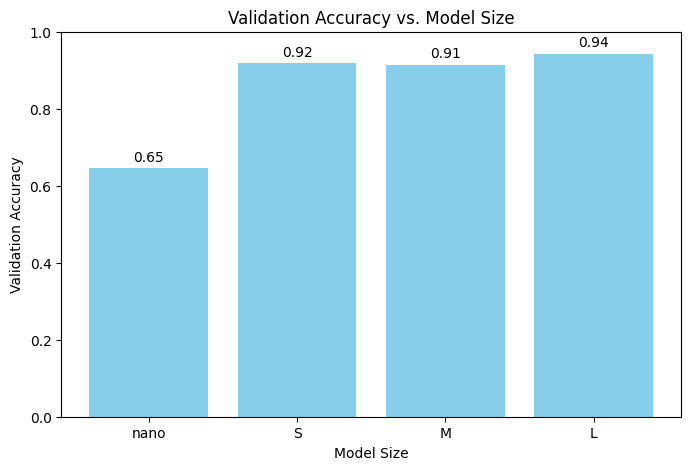

In [12]:
MODEL_CONFIGS = {
    "nano": {
        "fractal_blocks": 2,       # Not used directly here (we use 3 stages fixed)
        "depth_stage1": 2,         # Fractal depth in stage 1
        "depth_stage2": 2,         # Fractal depth in stage 2
        "depth_stage3": 2,         # Fractal depth in stage 3
        "base_filters": 16
    },
    "S": {
        "fractal_blocks": 2,
        "depth_stage1": 3,
        "depth_stage2": 3,
        "depth_stage3": 3,
        "base_filters": 32
    },
    "M": {
        "fractal_blocks": 3,
        "depth_stage1": 3,
        "depth_stage2": 4,
        "depth_stage3": 5,
        "base_filters": 32
    },
    "L": {
        "fractal_blocks": 3,
        "depth_stage1": 4,
        "depth_stage2": 4,
        "depth_stage3": 5,
        "base_filters": 64
    }
}

# ----------------------------------
# Model Components: SE, Recursive Fractal Block, and Spectral Branch
# ----------------------------------
def se_block(input_tensor, reduction=16):
    filters = int(input_tensor.shape[-1])
    se = layers.GlobalAveragePooling2D()(input_tensor)
    se = layers.Dense(filters // reduction, activation='relu')(se)
    se = layers.Dense(filters, activation='sigmoid')(se)
    return layers.multiply([input_tensor, se])

def recursive_fractal_block(x, filters, depth, drop_path_rate=0.2):
    shortcut = x
    if depth == 1:
        out = layers.Conv2D(filters, (3, 3), padding='same')(x)
        out = layers.BatchNormalization()(out)
        out = layers.Activation('relu')(out)
    else:
        left = recursive_fractal_block(x, filters, depth - 1, drop_path_rate)
        right = recursive_fractal_block(left, filters, depth - 1, drop_path_rate)
        if tf.random.uniform(()) > drop_path_rate:
            out = layers.Add()([left, right])
        else:
            out = left
        out = layers.Conv2D(filters, (3, 3), padding='same')(out)
        out = layers.BatchNormalization()(out)
        out = layers.Activation('relu')(out)
    
    # If input channels do not match, adjust via 1x1 conv
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1, 1), padding='same')(shortcut)
    
    out = layers.Add()([shortcut, out])
    out = layers.BatchNormalization()(out)
    out = layers.Activation('relu')(out)
    return out

def spectral_branch(x, embedding_dim=64):
    s = layers.GlobalAveragePooling2D()(x)
    s = layers.Dense(128, activation='relu')(s)
    s = layers.Dense(embedding_dim, activation='relu')(s)
    return s

# ----------------------------------
# Modular FractalNet Model Definition
# ----------------------------------
def fractalnet_model(model_size="M", input_shape=(224, 224, 1), num_classes=24, drop_path_rate=0.2):
    config = MODEL_CONFIGS[model_size]
    base_filters = config["base_filters"]
    
    inputs = Input(shape=input_shape)
    
    # Initial convolution
    x = layers.Conv2D(base_filters, (7, 7), strides=2, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    
    # Stage 1: Use depth_stage1
    x = recursive_fractal_block(x, base_filters * 2, depth=config["depth_stage1"], drop_path_rate=drop_path_rate)
    x = se_block(x)
    block1_output = layers.MaxPooling2D(pool_size=(2, 2), name="block1_output")(x)
    
    # Stage 2: Use depth_stage2 (increase filters)
    x = recursive_fractal_block(block1_output, base_filters * 4, depth=config["depth_stage2"], drop_path_rate=drop_path_rate)
    x = se_block(x)
    block2_output = layers.MaxPooling2D(pool_size=(2, 2), name="block2_output")(x)
    
    # Stage 3: Use depth_stage3 (increase filters further)
    x = recursive_fractal_block(block2_output, base_filters * 8, depth=config["depth_stage3"], drop_path_rate=drop_path_rate)
    x = se_block(x)
    block3_output = layers.MaxPooling2D(pool_size=(2, 2), name="block3_output")(x)
    
    # Feature Aggregation from Fractal Branch
    avg_pool = layers.GlobalAveragePooling2D()(block3_output)
    max_pool = layers.GlobalMaxPooling2D()(block3_output)
    classification_features = layers.Concatenate()([avg_pool, max_pool])
    
    # Spectral Branch: extract spectral embedding from block3 features
    spectral_features = spectral_branch(block3_output, embedding_dim=64)
    
    # Merge both branches
    merged_features = layers.Concatenate()([classification_features, spectral_features])
    
    # Dense Head for Classification
    x = layers.Dense(256, activation='relu')(merged_features)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name="predictions")(x)
    
    model = Model(inputs=inputs, outputs=outputs, name=f"FractalNet_{model_size}")
    return model

# ----------------------------------
# Training Loop for Different Model Sizes
# ----------------------------------
# Please ensure that X_train, Y_train, X_val, Y_val are available from the dataset loading section above.
accuracy_results = {}

for model_size in MODEL_CONFIGS.keys():
    print(f"\nTraining model variant: {model_size}")
    model_variant = fractalnet_model(model_size=model_size, input_shape=(224,224,1), num_classes=24)
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4, clipnorm=1.0)
    model_variant.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=['accuracy']
    )
    
    # Train the model; adjust epochs and batch_size as needed.
    history = model_variant.fit(
        X_train, Y_train,
        epochs=25,
        batch_size=32,
        validation_data=(X_val, Y_val),
        callbacks=[ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=1)],
        shuffle=True,
        class_weight=class_weight_dict  # Use computed class weights
    )
    
    # Evaluate the variant on the validation set.
    results = model_variant.evaluate(X_val, Y_val, verbose=0)
    accuracy = results[1]  # Assuming the second metric is accuracy.
    accuracy_results[model_size] = accuracy
    print(f"Model size {model_size}: Validation Accuracy = {accuracy:.4f}")

# ----------------------------------
# Plot Model Size vs. Accuracy
# ----------------------------------
model_sizes = list(accuracy_results.keys())
accuracies = list(accuracy_results.values())

plt.figure(figsize=(8, 5))
bars = plt.bar(model_sizes, accuracies, color='skyblue')
plt.xlabel("Model Size")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy vs. Model Size")
plt.ylim(0, 1)  # Accuracy as a fraction between 0 and 1

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{acc:.2f}', ha='center', va='bottom')

plt.show()